In [1]:
import os
from sentinel import SentinelHubProcessor
from matplotlib import pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

c:\Work\HealthMap\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ClientID = os.getenv('ClientID')
ClientSecret = os.getenv('ClientSecret')

In [3]:
sentinel = SentinelHubProcessor(ClientID, ClientSecret)
sentinel.set_area_of_interest(36.168885,54.521928,36.227948,54.548073) # (36.296920,54.483245,36.312544,54.491472) # min_lon, min_lat, max_lon, max_lat - т.е. формат WGS84 (долгота, широта) - первые два числа - нижний левый угол, вторые два - верхний правый угол
sentinel.set_date('latest') # latest или 'YYYY-MM-DD'
sentinel.set_resolution(10) # 10 метров на пиксель
sentinel.set_channels('true_color') # true_color или ndvi
image_rgb = sentinel.get_data()
sentinel.set_channels('ndvi')
image_ndvi = sentinel.get_data()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00595..1.2278].


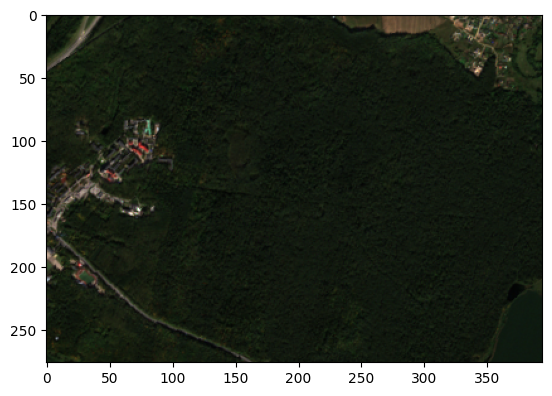

In [4]:
plt.imshow(image_rgb)

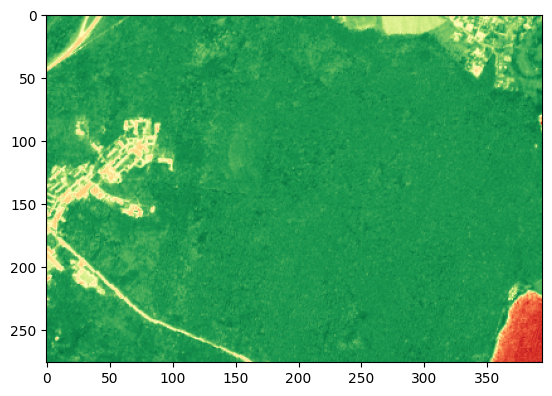

In [5]:
plt.imshow(image_ndvi,cmap='RdYlGn')

In [6]:
sentinel.set_channels('ndvi')
images, time_intervals = sentinel.get_monthly_images(18) # количество месяцев, включая текущий

Запуск сбора данных за последние 18 месяцев...
Запрос данных за период: 2025-09-02 по 2025-10-02
-> Успешно. Изображение добавлено.
Запрос данных за период: 2025-08-02 по 2025-09-02
-> Успешно. Изображение добавлено.
Запрос данных за период: 2025-07-02 по 2025-08-02
-> Успешно. Изображение добавлено.
Запрос данных за период: 2025-06-02 по 2025-07-02
-> Успешно. Изображение добавлено.
Запрос данных за период: 2025-05-02 по 2025-06-02
-> Успешно. Изображение добавлено.
Запрос данных за период: 2025-04-02 по 2025-05-02
-> Успешно. Изображение добавлено.
Запрос данных за период: 2025-03-02 по 2025-04-02
-> Успешно. Изображение добавлено.
Запрос данных за период: 2025-02-02 по 2025-03-02
-> Успешно. Изображение добавлено.
Запрос данных за период: 2025-01-02 по 2025-02-02
-> Успешно. Изображение добавлено.
Запрос данных за период: 2024-12-02 по 2025-01-02
-> Успешно. Изображение добавлено.
Запрос данных за период: 2024-11-02 по 2024-12-02
-> Успешно. Изображение добавлено.
Запрос данных за п

In [7]:
len(images)

18

In [47]:
# Разворачиваем список, чтобы анимация шла от прошлого к настоящему
images_for_animation = list(reversed(images)) 
# Длительность кадра в миллисекундах
interval_ms = 700


# --- Код анимации ---
if images_for_animation:
    fig = plt.figure(figsize=(6, 6))
    plt.axis('off') # Отключаем оси координат
    
    # Отображаем первый кадр
    img_obj = plt.imshow(np.clip(images_for_animation[0], 0, 1), cmap='RdYlGn') # cmap='RdYlGn' нужен для корректного отображения NDVI

    # Функция, которая будет обновлять кадр
    def update(frame):
        # Не забываем про clip, так как яркость может быть > 1
        img_obj.set_data(np.clip(images_for_animation[frame], 0, 1))
        return [img_obj]

    # Создаем объект анимации
    anim = FuncAnimation(fig, update, frames=len(images_for_animation), interval=interval_ms, blit=True)

    # Отображаем как HTML5 видео
    plt.close() # Закрываем статичное изображение, чтобы не было дублирования
    display(HTML(anim.to_html5_video()))

In [31]:
[interval[0][4:7] for interval in time_intervals]

['-09',
 '-08',
 '-07',
 '-06',
 '-05',
 '-04',
 '-03',
 '-02',
 '-01',
 '-12',
 '-11',
 '-10',
 '-09',
 '-08',
 '-07',
 '-06',
 '-05',
 '-04']

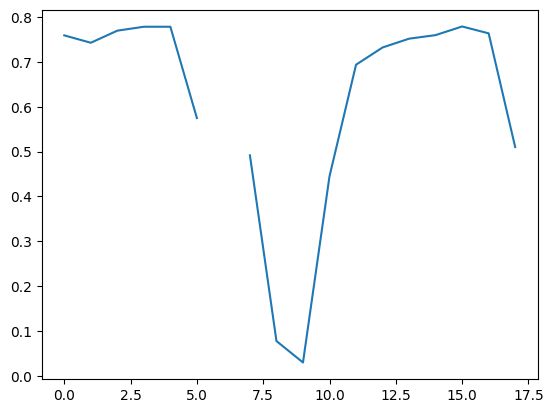

In [45]:
mean_ndvis = [np.mean(ndvi) for ndvi in images]
plt.plot(mean_ndvis)